# Coadd PSF

In this pedagogical exercise, we generate a "1D galaxy", which we model as a Gaussian. We simulate a number of PSFs, each of which is 1D - Gaussian but of varying sizes. We then produce a coadd image by generating arbitrary weights and performing a weighted average.

$$I_\text{coadd}(x) = \frac{\sum_{i=1}^{n_\text{sims}} w_i(x) I_i(x)}{\sum_{j=1}^{n_\text{sims}}}$$,

where

$$I_i(x) = \int\mathrm{d}x' T(x') P_i(x-x')$$


We conclude by showing that $I_\text{coadd}(x)$ can also be expressed as $\int\mathrm{d}x' T(x') P_\text{coadd}(x-x')$,
where


$$P_\text{coadd}(x) = \frac{\sum_{i=1}^{n_\text{sims}} w_i(x) P_i(x)}{\sum_{j=1}^{n_\text{sims}}}$$

In [1]:
import sys
sys.path.append('/software/lsstsw/stack_20210813/conda/miniconda3-py38_4.9.2/envs/lsst-scipipe/lib/python3.8/site-packages/')

import numpy as np
import scipy.signal

from ipywidgets import *
import matplotlib
%matplotlib notebook
import matplotlib.pyplot as plt

In [2]:
INV2PI = 1./np.sqrt(2*np.pi)
gal_size = 2.0
n_sims = 100
psf_sizes = np.random.uniform(low=1.0, high=1.6, size=n_sims)
A = 100
sizes = [np.hypot(p, gal_size) for p in psf_sizes]
backgrounds = np.random.uniform(low=100, high=200, size=n_sims)

In [3]:
# Generate the individual signals
X = np.linspace(-20, 20, 401)
T = A*np.exp(-0.5*X**2/gal_size**2)
Y = []
for i in range(n_sims):
    s = sizes[i]
    bg = backgrounds[i]
    p = INV2PI*np.exp(-0.5*X**2/psf_sizes[i]**2)/psf_sizes[i]
    y = scipy.signal.convolve(T, p, mode="same")
    n = np.random.randn(len(X))*np.sqrt(bg)
    Y.append(y)

In [9]:
# Visualize the individual signals
%matplotlib inline
@interact(n=(0, n_sims, 1))
def update(n=0):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    label = f"$n = {n}$"
    ax.plot(X, Y[n], label=label)
    ax.axhline(0.0, ls=':', color='gray', alpha=0.9)
    ax.set_title("Individual exposure")
    ax.legend()
    #fig.canvas.draw()

interactive(children=(IntSlider(value=0, description='n'), Output()), _dom_classes=('widget-interact',))

In [5]:
# Get the weights
W = []
for i in range(n_sims):
    # Spatially uncorrelated weights
    w = np.random.uniform(0.6, 1.5, size=len(X))
    w += (X>0)*10
    W.append(w)

<IPython.core.display.Javascript object>


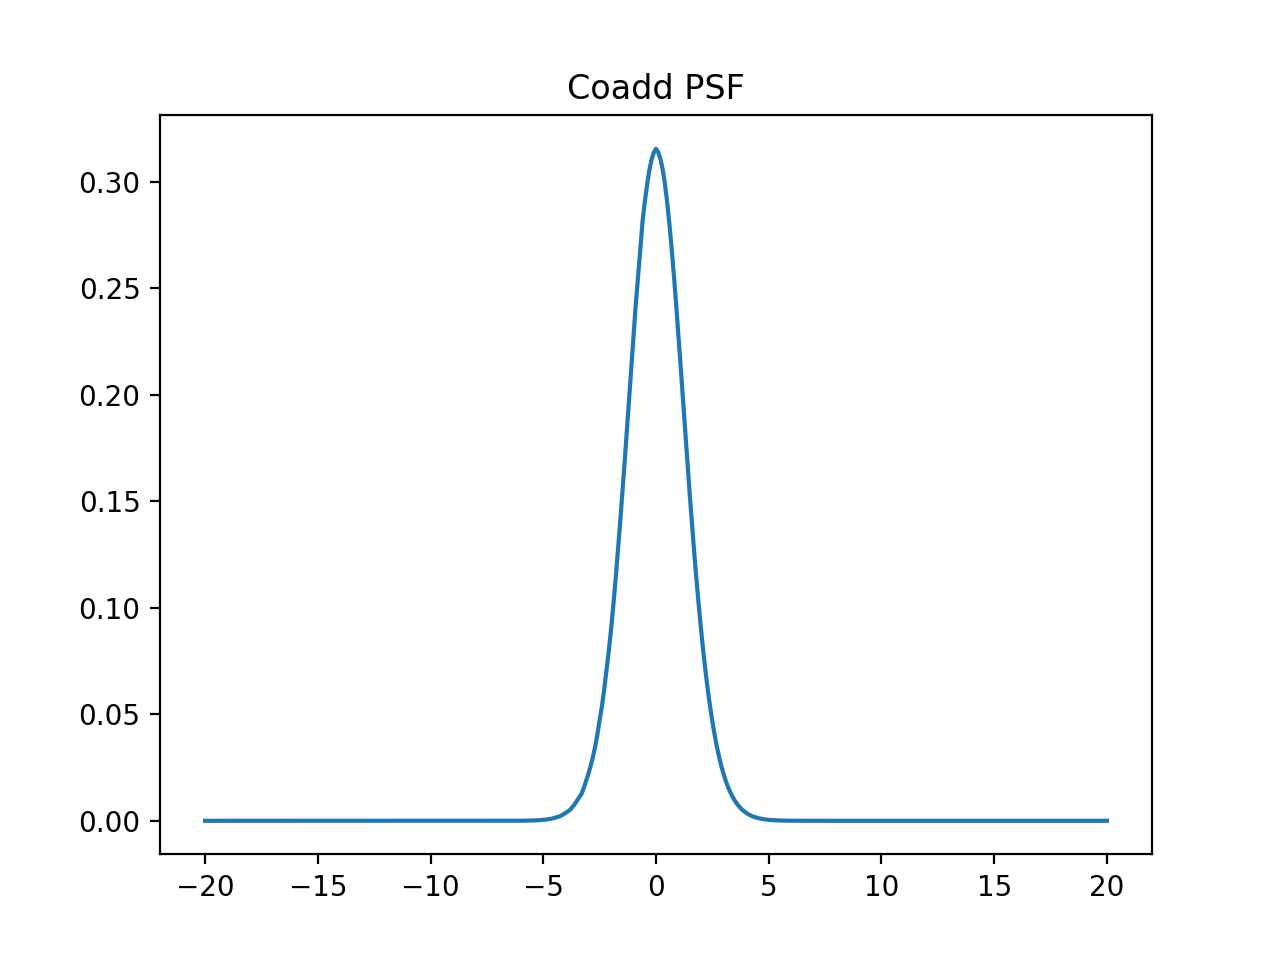

Text(0.5, 1.0, 'Coadd PSF')

In [15]:
# Generate the coadd PSF
%matplotlib notebook
P = np.zeros_like(X)
for i in range(n_sims):
    s = psf_sizes[i]
    p = INV2PI*np.exp(-0.5*X**2/s**2)/s
    P += W[i]*p
    
P /= sum((W[i] for i in range(n_sims)))
plt.plot(X, P)
plt.title("Coadd PSF")

In [16]:
# Generate the coadd
C = sum((W[i]*Y[i] for i in range(n_sims)))/sum((W[i] for i in range(n_sims)))
G = scipy.signal.convolve(T, P, mode="same")

<IPython.core.display.Javascript object>


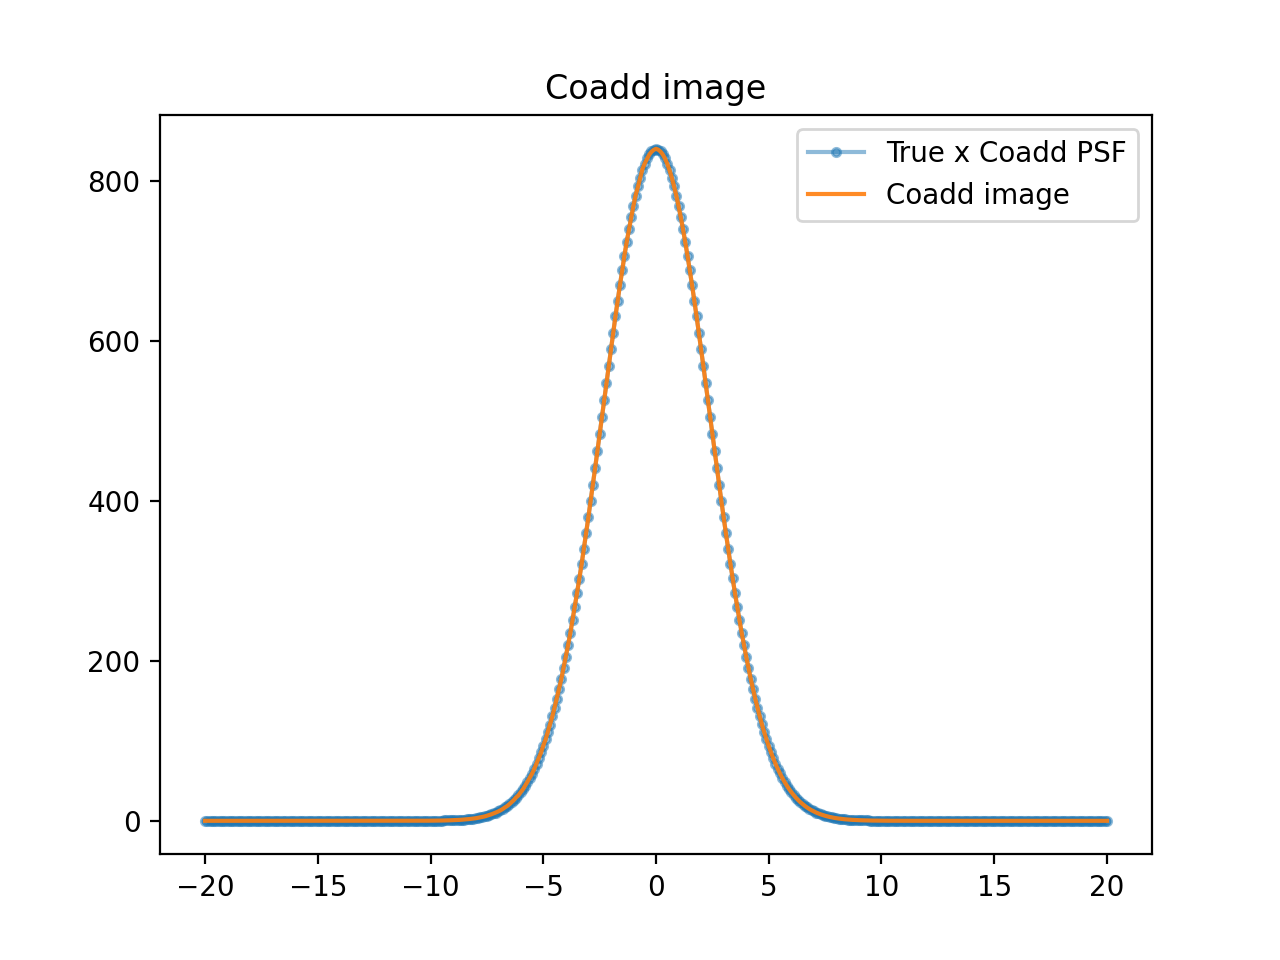

In [17]:
plt.plot(X, G, '.-', alpha=0.5, label="True x Coadd PSF")
plt.plot(X, C, label="Coadd image", alpha=0.9)
plt.title("Coadd image")
plt.legend(loc="best")